In [18]:
import numpy as np
from scipy.linalg import expm
import matplotlib.pyplot as plt

# --- helpers -------------------------------------------------
def kron_n(op_list):
    """Kronecker product of list of operators"""
    out = op_list[0]
    for op in op_list[1:]:
        out = np.kron(out, op)
    return out

def build_single_site_op(n, op, site):
    """Return I^{⊗site} ⊗ op ⊗ I^{⊗(n-site-1)}"""
    I2 = np.eye(2, dtype=complex)
    return kron_n([op if i == site else I2 for i in range(n)])

def lindblad_super(L, d):
    return (np.kron(L, L.conj()) -
            0.5 * np.kron(np.eye(d), L.conj().T @ L) -
            0.5 * np.kron((L.conj().T @ L).T, np.eye(d)))

# --- system parameters --------------------------------------
k = 4                      # number of atoms (small for demo)
V0 = 40 * 1e6  * 2*np.pi     # nearest-neighbour interaction (Hz)
t_ramp_up = 0.33e-6
t_ramp_down = 0.33e-6
t_sweep = 0.34e-6
T_total = t_ramp_up + t_sweep + t_ramp_down
Omega_max = 3e6 * 2*np.pi  # convert to angular freq
Delta_start = -4e6 * 2*np.pi
Delta_end   =  4e6 * 2*np.pi
T2 = 6e-6                 # coherence time (s)
gamma = 1 / T2
# gamma = 0 #use no decoherence
num_steps = 1000            # time slices
dt = T_total / num_steps
t_grid = np.linspace(0, T_total, num_steps)

# pauli matrices and projector
X = np.array([[0, 1], [1, 0]], dtype=complex)
Pr = np.array([[0, 0],
               [0, 1]], dtype=complex)
I2 = np.eye(2, dtype=complex)

# --- ramp profiles ------------------------------------------
Omega_t = np.zeros_like(t_grid)
Delta_t = np.zeros_like(t_grid)
for idx, t in enumerate(t_grid):
    if t < t_ramp_up:
        Omega_t[idx] = Omega_max * (t / t_ramp_up)
        Delta_t[idx] = Delta_start
    elif t < t_ramp_up + t_sweep:
        Omega_t[idx] = Omega_max
        s = (t - t_ramp_up) / t_sweep
        Delta_t[idx] = Delta_start + (Delta_end - Delta_start) * s
    else:
        Omega_t[idx] = Omega_max * (1 - (t - t_ramp_up - t_sweep) / t_ramp_down)
        Delta_t[idx] = Delta_end

# --- precompute single‑site ops ------------------------------
X_ops = [build_single_site_op(k, X, j) for j in range(k)]
Pr_ops = [build_single_site_op(k, Pr, j) for j in range(k)]

# initial state |0...0⟩
d = 2**k
rho = np.zeros((d, d), dtype=complex)
rho[0, 0] = 1.0
rho_vec = rho.flatten()

# precompute Liouvillian components that don't change with time
L_jump_total = np.zeros((d*d, d*d), dtype=complex)
for j in range(k):
    L_jump_total += lindblad_super(np.sqrt(2*gamma) * Pr_ops[j], d)


# stuff to keep track of
populations = np.zeros((num_steps, d), dtype=float)

# --- time evolution -----------------------------------------
for idx in range(num_steps):
    # build instantaneous Hamiltonian H(t)
    H_drive = sum(Omega_t[idx]/2 * X_ops[j] for j in range(k))
    H_det   = sum(-Delta_t[idx] * Pr_ops[j] for j in range(k))
    H_int = sum(V0 * Pr_ops[i] @ Pr_ops[i+1] for i in range(k - 1)) + V0 * Pr_ops[k-1] @ Pr_ops[0]
    H_t = H_drive + H_det + H_int

    L_coherent = -1j * (np.kron(H_t, np.eye(d)) - np.kron(np.eye(d), H_t.T))
    L_total = L_coherent + L_jump_total

    # propagate one step
    U = expm(L_total * dt)
    rho_vec = U @ rho_vec

    populations[idx] = np.real(np.diag(rho_vec.reshape(d, d)))  # only store real part (imag due to rounding


# reshape back to matrix, Hermitianise & normalise
rho_t = rho_vec.reshape(d, d)
# rho_t = 0.5 * (rho_t + rho_t.conj().T)
# rho_t /= np.trace(rho_t)
rho_t


#fidelity calculation:


basis_size = 2 ** k
d = basis_size
basis_1010 = np.zeros((d,), dtype=complex)
basis_0101 = np.zeros((d,), dtype=complex)
basis_1010[int('1010', 2)] = 1.0
basis_0101[int('0101', 2)] = 1.0
psi_target = (basis_1010 + basis_0101) / np.sqrt(2)
rho_target = np.outer(psi_target, psi_target.conj())
# Reshape vectorized rho to density matrix form
rho_final = rho_vec.reshape((d, d))
# Compute fidelity: ⟨ψ|ρ|ψ⟩ if one is pure
fidelity = np.real(psi_target.conj().T @ rho_final @ psi_target)

In [19]:
rho_final
populations[-1]
fidelity

eigvals, eigvecs = np.linalg.eigh(rho_final)
#principle eigenvector fidelity
principal_index = np.argmax(eigvals)
psi_principal = eigvecs[:, principal_index]
pfidelity = np.abs(np.vdot(psi_target, psi_principal))**2
print("Fidelity", fidelity)
print("Fidelity between principle eigenvector and target state:", pfidelity)

Fidelity 0.8284986603752338
Fidelity between principle eigenvector and target state: 0.9972306197469424


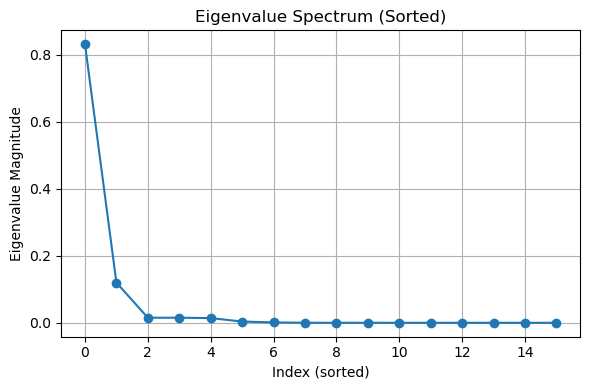

array([8.30767859e-01, 1.19922670e-01, 1.51182659e-02, 1.51182659e-02,
       1.40093475e-02, 3.77927240e-03, 1.11354783e-03, 5.73953832e-05,
       3.12213069e-05, 3.12213069e-05, 1.07191050e-05, 1.05530145e-05,
       1.05530145e-05, 1.03822712e-05, 8.72492413e-06, 6.29414170e-10])

In [20]:
import sympy as sp

# Use real part if matrix is symmetric or Hermitian; otherwise, use absolute value
spectrum = np.sort(np.abs(eigvals))[::-1]  # descending order

# Plot spectrum
plt.figure(figsize=(6, 4))
plt.plot(spectrum, marker='o', linestyle='-')
plt.title('Eigenvalue Spectrum (Sorted)')
plt.xlabel('Index (sorted)')
plt.ylabel('Eigenvalue Magnitude')
plt.grid(True)
plt.tight_layout()
plt.show()
spectrum 

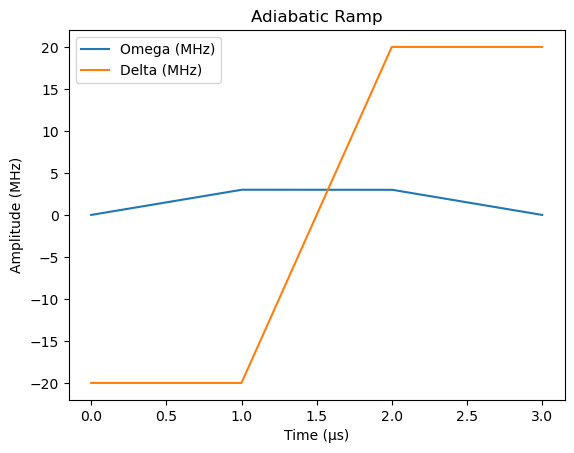

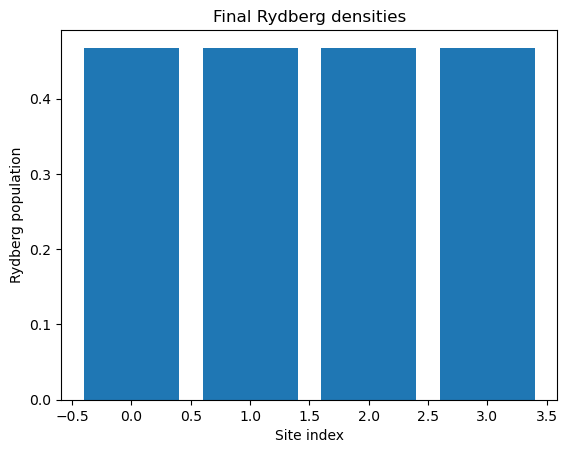

In [16]:
# --- observables: Rydberg density on each site --------------
densities = [np.trace(rho_t @ Pr_ops[j]).real for j in range(k)]

# --- plotting ------------------------------------------------
fig, ax = plt.subplots()
ax.plot(t_grid*1e6, Omega_t/(2*np.pi*1e6), label="Omega (MHz)")
ax.plot(t_grid*1e6, Delta_t/(2*np.pi*1e6), label="Delta (MHz)")
ax.set_xlabel("Time (μs)")
ax.set_ylabel("Amplitude (MHz)")
ax.set_title("Adiabatic Ramp")
ax.legend()
plt.show()

fig2, ax2 = plt.subplots()
ax2.bar(range(k), densities)
ax2.set_xlabel("Site index")
ax2.set_ylabel("Rydberg population")
ax2.set_title("Final Rydberg densities")
plt.show()

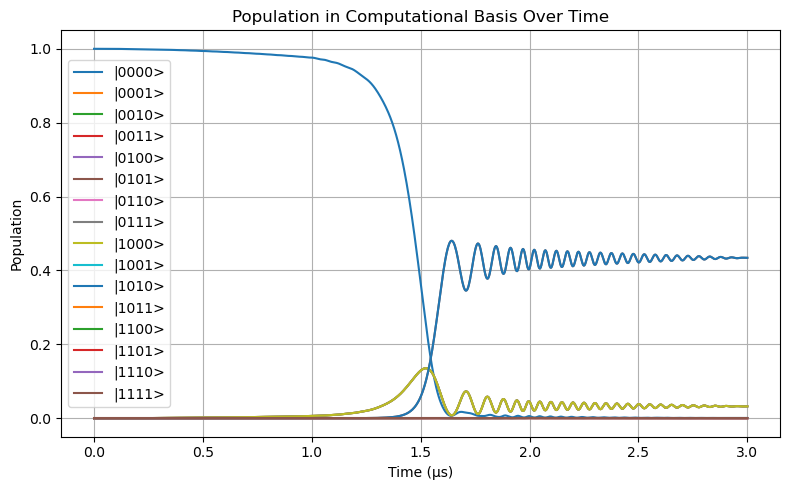

In [17]:
#evolution of population
plt.figure(figsize=(8, 5))
for i in range(d):  # states |000⟩ and |111⟩
    plt.plot(t_grid * 1e6, populations[:, i], label=f"|{format(i, f'0{k}b')}>")
plt.xlabel("Time (µs)")
plt.ylabel("Population")
plt.legend()
plt.title("Population in Computational Basis Over Time")
plt.grid(True)
plt.tight_layout()
plt.show()